In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree

Matplotlib is building the font cache; this may take a moment.


In [11]:
# Load the data from Excel

# file_path = "Random Forest Input.xlsx"
file_path = 'Enhanced Random Forest Input.xlsx'
# file_path = 'NonEnsemble-Enhanced Random Forest Input.xlsx'

In [14]:
df = pd.read_excel(file_path)

# Display the first few rows to understand the structure
print(df.head())

   Avg Proximal  Max Proximal  Min Proximal  Heart Rate Proximal  \
0     65.770925     85.463016     49.415180            85.106383   
1     66.249477     91.675121     38.794859            83.333333   
2     67.656007     83.954351     43.534909           136.363636   
3     68.331497     84.546948     54.127414           121.212121   
4     64.790551     86.567932     43.675974            89.552239   

   Pulse Pressure Proximal  Augmentation Pressure Proximal  \
0                36.047836                      -19.792531   
1                52.880262                      -28.139389   
2                40.419442                      -13.744257   
3                30.419535                      -15.058305   
4                42.891959                      -25.820653   

   Pseudo-Map Proximal  Inflection Time Proximal  \
0            61.431125                     0.350   
1            56.421613                     0.370   
2            57.008056                     0.220   
3         

In [15]:
sample_len=df.shape[0]
print(sample_len)

162


In [16]:

# Preprocess data
# Drop rows with missing target values
df = df.dropna(subset=['Hemorrhage Level'])

# Separate features and target
X = df.drop(columns=['Hemorrhage Level', 'Patient ID'])
y = df['Hemorrhage Level']

# Encode categorical features if necessary
X = pd.get_dummies(X, drop_first=True)  # Convert categorical variables to dummy variables

# Encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Class balancing with SMOTE on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Calculate the size of the smallest class in the test set
counter = Counter(y_test)
min_class_size = min(counter.values())

# Drop elements from overrepresented classes in the test set
X_test_balanced = pd.DataFrame()
y_test_balanced = []
for cls, count in counter.items():
    indices = np.where(y_test == cls)[0]
    if count > min_class_size:
        drop_indices = np.random.choice(indices, size=count - min_class_size, replace=False)
        X_test_balanced = pd.concat([X_test_balanced, X_test.drop(X_test.index[drop_indices]).reset_index(drop=True)])
        y_test_balanced.extend(y_test[np.isin(np.arange(len(y_test)), np.setdiff1d(np.arange(len(y_test)), drop_indices))])
    else:
        X_test_balanced = pd.concat([X_test_balanced, X_test.iloc[indices]])
        y_test_balanced.extend(y_test[indices])

# Convert y_test_balanced to numpy array
y_test_balanced = np.array(y_test_balanced)

# Trim to the size of the smallest class
counter_balanced = Counter(y_test_balanced)
min_class_size_balanced = min(counter_balanced.values())

# Ensure close to the minimum class size samples per class in the test set
X_test_balanced_trimmed = pd.DataFrame()
y_test_balanced_trimmed = []
desired_class_size = min(min(sample_len/4, min_class_size_balanced), min_class_size)  # Example: Close to 4 samples per class or the minimum class size

for cls, count in counter_balanced.items():
    indices = np.where(y_test_balanced == cls)[0]
    np.random.shuffle(indices)  # shuffle indices
    keep_indices = indices[:min(desired_class_size, count)]  # keep up to desired_class_size samples or less if count < desired_class_size
    X_test_balanced_trimmed = pd.concat([X_test_balanced_trimmed, X_test_balanced.iloc[keep_indices]])
    y_test_balanced_trimmed.extend(y_test_balanced[keep_indices])

# Convert y_test_balanced_trimmed to numpy array
y_test_balanced_trimmed = np.array(y_test_balanced_trimmed)

# Train a Decision Tree Classifier with hyperparameters
clf = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy'
    splitter='best',   # or 'random'
    max_depth=None,    # or any integer value
    min_samples_split=2,  # or any integer value
    min_samples_leaf=1,  # or any integer value
    max_features=None,  # or 'auto', 'sqrt', 'log2'
    random_state=42
)

clf.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred = clf.predict(X_test_balanced_trimmed)

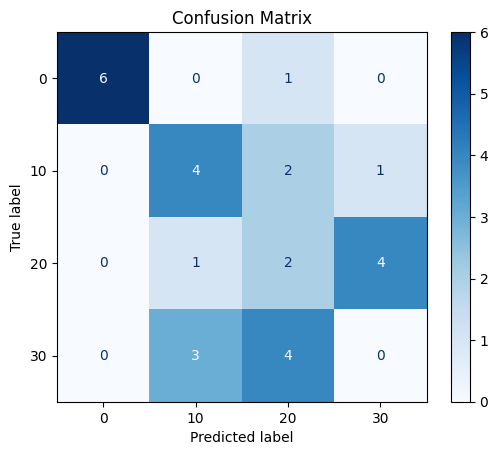

Accuracy: 0.42857142857142855


In [17]:

# Evaluate the model
# Confusion Matrix
cm = confusion_matrix(y_test_balanced_trimmed, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Accuracy
accuracy = accuracy_score(y_test_balanced_trimmed, y_pred)
print(f"Accuracy: {accuracy}")



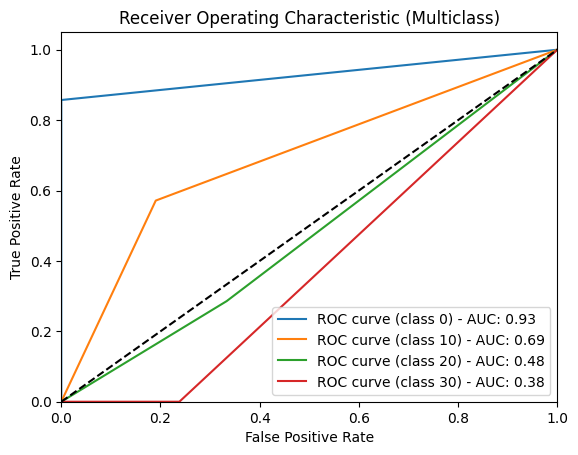

In [18]:
# # ROC Curve for multiclass
# y_test_binarized = label_binarize(y_test_balanced_trimmed, classes=np.unique(y))
# y_pred_proba = clf.predict_proba(X_test_balanced_trimmed)

# plt.figure()
# for i in range(y_test_binarized.shape[1]):
#     fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
#     plt.plot(fpr, tpr, label=f'ROC curve (class {label_encoder.classes_[i]})')

# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (Multiclass)')
# plt.legend(loc='lower right')
# plt.show()

from sklearn.metrics import auc

# ROC Curve for multiclass with AUC
y_test_binarized = label_binarize(y_test_balanced_trimmed, classes=np.unique(y))
y_pred_proba = clf.predict_proba(X_test_balanced_trimmed)

plt.figure()
for i in range(y_test_binarized.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (class {label_encoder.classes_[i]}) - AUC: {roc_auc:.2f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Multiclass)')
plt.legend(loc='lower right')
plt.show()

In [19]:
# # F1 Score
# f1 = f1_score(y_test_balanced_trimmed, y_pred, average='weighted')
# print(f"F1 Score: {f1:.2f}")

from sklearn.metrics import f1_score, classification_report

# Calculate F1 Scores
f1_scores = f1_score(y_test_balanced_trimmed, y_pred, average=None)
print("\nF1 Scores per Class:\n")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"F1 Score for class '{class_name}': {f1_scores[i]:.4f}")



F1 Scores per Class:

F1 Score for class '0': 0.9231
F1 Score for class '10': 0.5333
F1 Score for class '20': 0.2500
F1 Score for class '30': 0.0000


In [20]:
# Convert the class labels to strings
class_names = list(map(str, label_encoder.classes_))


# Plot the Decision Tree
# plt.figure(figsize=(20, 10))
plt.figure(figsize=(20, 10), dpi=600)
plot_tree(clf, 
          filled=True, 
          feature_names=X.columns.tolist(), 
          class_names=class_names,  # Pass the class names as strings
          rounded=True)

# Save the Decision Tree as an image file
output_image_path = "decision_tree_visualization.png"
plt.savefig(output_image_path, bbox_inches='tight')
plt.close()

print(f"Decision tree image saved as {output_image_path}")

Decision tree image saved as decision_tree_visualization.png


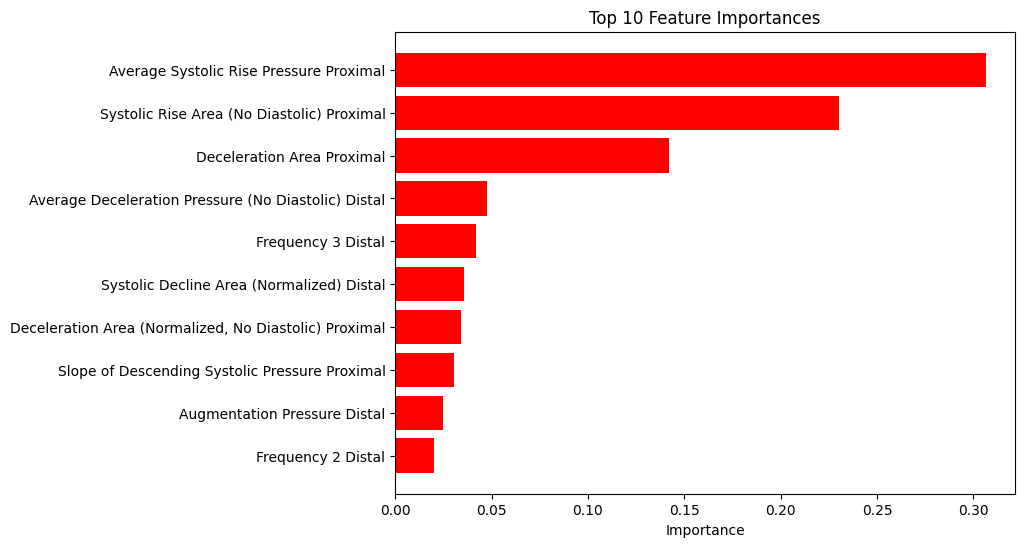

In [21]:
# # Plot Feature Importance
# importances = clf.feature_importances_
# indices = np.argsort(importances)[::-1]  # Sort in descending order

# plt.figure(figsize=(12, 8))
# plt.title("Feature Importance")
# plt.bar(range(X.shape[1]), importances[indices], align='center')
# plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
# plt.xlim([-1, X.shape[1]])
# plt.tight_layout()


# Plot Feature Importances (Horizontal Bar Plot for Top 10 Features)
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort in descending order

# Only consider the top 10 features
top_n = 10
top_indices = indices[:top_n]

plt.figure(figsize=(8, 6))
plt.title("Top 10 Feature Importances")
plt.barh(range(top_n), importances[top_indices], color="r", align="center")
plt.yticks(range(top_n), X.columns[top_indices])
plt.xlabel("Importance")
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()